# Quantum CPR v2 — the continuous-variable protocol

My first attempt ([quantum_cpr.ipynb](quantum_cpr.ipynb)) tried to force the common-pool resource game into the **discrete EWL qubit protocol** (C/D/Q̂ strategies via Pauli gates). That hit a wall: EWL's cooperative fixed point only survives for an *even* number of players (a parity artifact of $\sigma_z^{\otimes n}$ vs $\sigma_x^{\otimes n}$), and it forces a continuous boat/uptake choice into an artificial binary strategy.

Grau-Climent et al. (*Entropy* 2023, 25, 1585) sidestep this entirely by using the **Li–Du–Massar continuous-variable (CV) quantization** instead. Strategies stay real numbers — no qubits, no binary C/D/Q̂ — and entanglement is one closed-form transformation. This notebook sketches that protocol for **two players, one cycle**: pick classical uptakes, entangle, measure, get quantum payoffs. No dynamics yet — that's for a follow-up.

Source: [entropy-25-01585-v3.pdf](../literature/quantum_games/entropy-25-01585-v3.pdf).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Act 1 — The classical Cournot-type CPR game

Two players each choose an uptake $g_i \geq 0$ (Grau-Climent's fishing/pasture analogy: "how many sheep/boats do I send out"). Total uptake is

$$G = g_1 + g_2.$$

Marginal cost per unit of uptake is $c_i$ (constant). The marginal *profit* per unit shrinks linearly as the total uptake approaches the resource's maximum capacity $G_{max}$:

$$v(G) = \begin{cases} v_0\left(1 - \dfrac{G}{k\,G_{max}}\right) & G \le G_{max} \\ 0 & G > G_{max} \end{cases}$$

$k \geq 1$ is an elasticity parameter ($k=1$: fully elastic, price hits zero exactly at $G_{max}$; $k\to\infty$: inelastic, $v(G)\to v_0$ regardless of $G$).

Player $i$'s classical profit is

$$u_i = g_i\bigl(v(G) - c_i\bigr) \qquad (G \le G_{max}).$$

This is the payoff we'll compare the entangled version against.

In [2]:
# ── Model parameters (paper's Cournot-type CPR) ────────────────────────────────
v0     = 1.0    # marginal profit at G=0
Gmax   = 10.0   # resource capacity
k      = 1.0    # elasticity (1.0 = fully elastic)
c1, c2 = 0.2, 0.2   # marginal cost per unit uptake, same for both (homogeneous players)

def v(G):
    """Marginal profit per unit of total uptake G."""
    G = np.asarray(G)
    return np.where(G <= Gmax, v0 * (1 - G / (k * Gmax)), 0.0)

def classical_payoffs(g1, g2):
    G = g1 + g2
    u1 = g1 * (v(G) - c1)
    u2 = g2 * (v(G) - c2)
    return u1, u2

# example: both players choose a moderate uptake
g1_classical, g2_classical = 3.0, 3.0
u1c, u2c = classical_payoffs(g1_classical, g2_classical)
print(f"Classical uptakes: g1={g1_classical}, g2={g2_classical}, G={g1_classical+g2_classical}")
print(f"Classical payoffs: u1={u1c:.4f}, u2={u2c:.4f}")

Classical uptakes: g1=3.0, g2=3.0, G=6.0
Classical payoffs: u1=0.6000, u2=0.6000


## Act 2 — The Li–Du–Massar entanglement protocol

Following Li, Du & Massar (2002), the game is embedded in a **continuous-variable quantum optics** setup — the classical Prisoner's-Dilemma-style EWL "qubit + entangling gate" picture is replaced by two field modes and a two-mode **squeezing operator**. The steps (Grau-Climent et al., Sec. 2):

1. **Initial state** $|00\rangle$ — vacuum in both modes.
2. **Entanglement operation** $\hat J(\gamma) = e^{-\gamma(\hat a_1^\dagger \hat a_2^\dagger - \hat a_1 \hat a_2)}$, a two-mode squeezing operator. $\gamma \geq 0$ is the *squeezing parameter*, playing the role entanglement plays in EWL.
3. **Strategic moves**: each player applies a displacement $\hat D_i(x_i) = e^{x_i(\hat a_i^\dagger - \hat a_i)/\sqrt2}$ — this is literally "choosing $g_i$": the classical uptake becomes the displacement amplitude.
4. **Disentanglement** $\hat J(\gamma)^\dagger$ undoes the squeezing.
5. **Measurement** of both modes' amplitude yields the *entangled* uptakes actually realized.

Working through the operator algebra (their Eq. 5), the measured uptakes come out as a simple linear mixing of the two classical choices:

$$g_1^c = g_1 \cosh\gamma + g_2 \sinh\gamma, \qquad g_2^c = g_2 \cosh\gamma + g_1 \sinh\gamma.$$

So each player's *realized* uptake now depends on **both** players' classical choices — that's entanglement made visible: your strategy leaks into my payoff and vice versa, with $\gamma$ controlling how much.

At $\gamma = 0$: $\cosh 0 = 1$, $\sinh 0 = 0$, so $g_i^c = g_i$ — we recover the classical game exactly, as expected.

In [3]:
def entangle(g1, g2, gamma):
    """Apply the Li-Du-Massar entanglement map (Eq. 5) to classical uptakes."""
    g1c = g1 * np.cosh(gamma) + g2 * np.sinh(gamma)
    g2c = g2 * np.cosh(gamma) + g1 * np.sinh(gamma)
    return g1c, g2c

def quantum_payoffs(g1, g2, gamma):
    """One full cycle: entangle -> measure -> pay off, Eq. (5)-(7)."""
    g1c, g2c = entangle(g1, g2, gamma)
    Gc = g1c + g2c
    u1 = g1c * (v(Gc) - c1)
    u2 = g2c * (v(Gc) - c2)
    return g1c, g2c, u1, u2

# same classical strategy choice as above, now entangled
gamma_demo = 0.5
g1c, g2c, u1q, u2q = quantum_payoffs(g1_classical, g2_classical, gamma_demo)

print(f"gamma = {gamma_demo}")
print(f"Classical choice:  g1={g1_classical}, g2={g2_classical}")
print(f"Entangled uptake:  g1^c={g1c:.4f}, g2^c={g2c:.4f}  (total G^c={g1c+g2c:.4f})")
print(f"Quantum payoffs:   u1={u1q:.4f}, u2={u2q:.4f}")
print(f"(for comparison, classical payoffs were u1={u1c:.4f}, u2={u2c:.4f})")

# sanity check: gamma = 0 must recover the classical game exactly
g1c0, g2c0, u1_0, u2_0 = quantum_payoffs(g1_classical, g2_classical, 0.0)
assert np.isclose(g1c0, g1_classical) and np.isclose(g2c0, g2_classical)
assert np.isclose(u1_0, u1c) and np.isclose(u2_0, u2c)
print("\ngamma=0 recovers the classical game: check passed.")

gamma = 0.5
Classical choice:  g1=3.0, g2=3.0
Entangled uptake:  g1^c=4.9462, g2^c=4.9462  (total G^c=9.8923)
Quantum payoffs:   u1=-0.9360, u2=-0.9360
(for comparison, classical payoffs were u1=0.6000, u2=0.6000)

gamma=0 recovers the classical game: check passed.


## What is actually measured? Quadrature, not photon number

The paper says "the final measurement gives the respective quantum uptakes $g_1^c, g_2^c$" without naming the observable — but the physics pins it down.

The displacement operator $\hat D_i(x_i) = e^{x_i(\hat a_i^\dagger - \hat a_i)/\sqrt2}$ acting on the vacuum produces a **coherent state** shifted along the **amplitude quadrature**

$$\hat X_i = \frac{\hat a_i^\dagger + \hat a_i}{\sqrt2}, \qquad \langle \hat X_i \rangle = x_i.$$

So a player's "move" is literally: *nudge my light mode's quadrature by $x_i = g_i$*. The entangling operation $\hat J(\gamma)$ is a two-mode squeezer, which mixes the two players' quadratures together (the CV analogue of an EPR pair of light beams); $\hat J(\gamma)^\dagger$ partially undoes this. What comes out at the end is read off by **homodyne detection** of each mode's quadrature — the standard readout for continuous-variable / squeezed-light experiments. That homodyne reading *is* $g_i^c$.

This is **not** a photon-number measurement. Photon number $\hat n_i = \hat a_i^\dagger \hat a_i$ is quadratic in the field amplitude, so if that were the observable, $g_i^c$ would come out quadratic in $g_1, g_2, \cosh\gamma, \sinh\gamma$. But Eq. (5) is manifestly *linear* in those quantities — the only observable consistent with that linear shape is the quadrature $\hat X_i$, not $\hat n_i$.

**Translating back to the fishery story:** "how much fish player $i$ actually caught" is the homodyne-measured quadrature amplitude of their light mode after the squeeze → displace → unsqueeze sequence — not a count of discrete quanta. Grau-Climent et al. inherit this readout unchanged from Li–Du–Massar (their Eq. 5 is the same formula); they never introduce a photon-counting step, so the "quantum uptake" in the CPR game is this same quadrature reading, just relabeled as boats/sheep/fish caught.

## Act 3 — How much "quantum" is there? On the range of $\gamma$

Unlike the discrete EWL picture (where entanglement is bounded — a single qubit pair maxes out at a Bell state), here $\gamma \in [0, \infty)$ has **no finite upper bound**. Both $\cosh\gamma$ and $\sinh\gamma$ grow without limit, so there's no "maximally entangled" $\gamma$ analogous to a Bell state — more $\gamma$ always means more mixing.

What *does* bound $\gamma$ in practice is economics, not physics: the entangled uptakes and total $G^c$ must stay in a range where the game still makes sense —

- uptakes should stay non-negative and finite,
- ideally $G^c \lesssim G_{max}$, otherwise $v(G^c)$ collapses to zero and both players earn nothing (or lose money on cost).

So "the most quantum limit" is best read as *the largest $\gamma$ for which the entangled Nash equilibrium $E^{(4)}$ (Grau-Climent Eq. 17) still gives positive, sensible uptakes* — not a hard cutoff built into the formalism itself. Let's see this directly: sweep $\gamma$ for a fixed classical choice and watch $G^c$ blow past $G_{max}$.

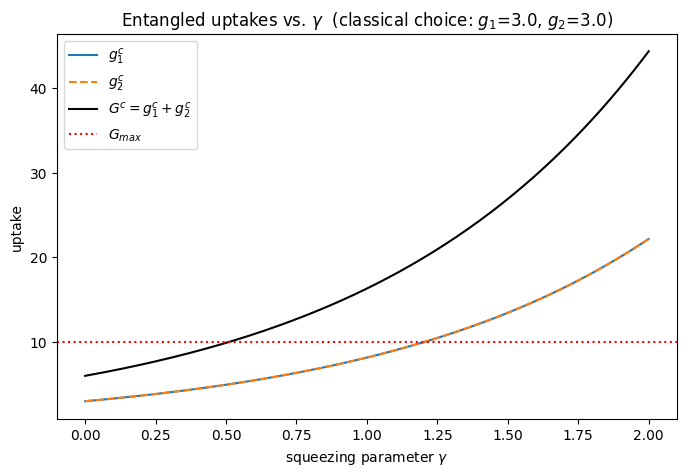

G^c exceeds G_max at gamma ~ 0.513


In [4]:
gammas = np.linspace(0, 2.0, 200)
g1c_sweep, g2c_sweep = entangle(g1_classical, g2_classical, gammas)
Gc_sweep = g1c_sweep + g2c_sweep

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(gammas, g1c_sweep, label="$g_1^c$")
ax.plot(gammas, g2c_sweep, label="$g_2^c$", linestyle="--")
ax.plot(gammas, Gc_sweep, label="$G^c = g_1^c + g_2^c$", color="black")
ax.axhline(Gmax, color="red", linestyle=":", label="$G_{max}$")
ax.set_xlabel(r"squeezing parameter $\gamma$")
ax.set_ylabel("uptake")
ax.set_title(f"Entangled uptakes vs. $\\gamma$  (classical choice: $g_1$={g1_classical}, $g_2$={g2_classical})")
ax.legend()
plt.show()

# where does G^c first cross G_max?
cross_idx = np.argmax(Gc_sweep > Gmax)
if Gc_sweep[cross_idx] > Gmax:
    print(f"G^c exceeds G_max at gamma ~ {gammas[cross_idx]:.3f}")
else:
    print("G^c never exceeds G_max over this sweep.")

## Payoff landscape over $\gamma$

Holding the classical strategy choice fixed, how do the *quantum* payoffs move as we dial up entanglement?

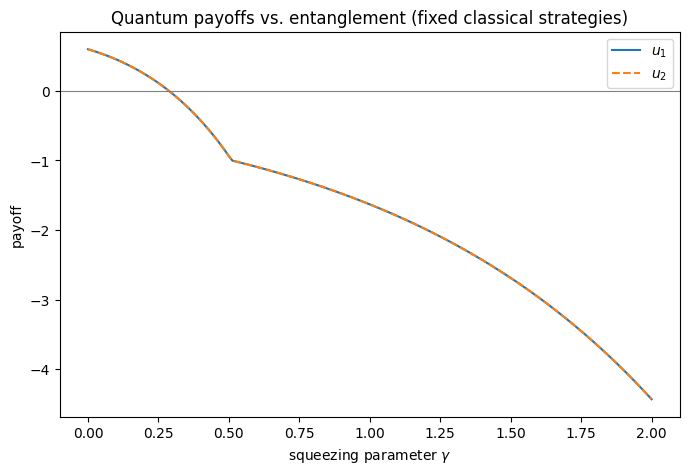

In [5]:
u1_sweep = np.zeros_like(gammas)
u2_sweep = np.zeros_like(gammas)
for i, gam in enumerate(gammas):
    _, _, u1_sweep[i], u2_sweep[i] = quantum_payoffs(g1_classical, g2_classical, gam)

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(gammas, u1_sweep, label="$u_1$")
ax.plot(gammas, u2_sweep, label="$u_2$", linestyle="--")
ax.axhline(0, color="gray", linewidth=0.8)
ax.set_xlabel(r"squeezing parameter $\gamma$")
ax.set_ylabel("payoff")
ax.set_title("Quantum payoffs vs. entanglement (fixed classical strategies)")
ax.legend()
plt.show()

## Next steps

This notebook only sketches **one cycle**: entangle → play → disentangle → measure → payoff, for a single fixed classical strategy pair. It deliberately stops short of:

- the boundedly-rational best-response dynamics $g_i(t+1)$ (Grau-Climent Eqs. 8–11),
- locating and checking stability of the entangled Nash equilibrium $E^{(4)}$ (their Eqs. 17, 21),
- and the open question from [quantum_games_literature_notes.mdx](quantum_games_literature_notes.mdx): whether an entangled equilibrium can avoid overexploitation the way $(\hat Q,\hat Q)$ avoided mutual defection in [quantum_pd.ipynb](quantum_pd.ipynb).

Those belong in a `quantum_cpr_v3` once the one-cycle mechanics above feel solid.